In [1]:
import xarray as xr
import dask
import numpy as np
import matplotlib.pyplot as plt
import cartopy  # Map projections libary
import cartopy.crs as ccrs  # Projections list
from scipy.interpolate import CubicSpline
import copy
import pandas as pd
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from GLODAP_gridding_tools import *

In [2]:
plotsdir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/figures/" + x
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/observations/" + x

## Load in GLODAPv2

In [3]:
ds = pd.read_csv(datadir('GLODAPv2.2023_Merged_Master_File.csv'),na_values=9999)
ds = ds.replace(-9999, np.nan)

/tmp/ipykernel_40925/2440561600.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  ds = pd.read_csv(datadir('GLODAPv2.2023_Merged_Master_File.csv'),na_values=9999)


In [4]:
ds['sa'] = gsw.SA_from_SP(
        ds.G2salinity,
        ds.G2pressure,
        ds.G2longitude,
        ds.G2latitude)
ds['ct'] = gsw.CT_from_t(
        ds.sa,
        ds.G2temperature,
        ds.G2pressure)

ds['sigma2'] = gsw.sigma2(
        ds.sa,
        ds.ct)

## Select objective grid, variables and year 

In [5]:
regular_lon = np.arange(-180., 180., 1.5)
regular_lat = np.arange(-90., 90., 1.5)
gridded_sigma2 = np.array([36.9415 , 36.974  , 37.002  , 37.02625, 37.0475 , 37.0665 , 37.08375,
       37.1    , 37.116  , 37.132  , 37.148  , 37.164  , 37.18   , 37.1965 ,
       37.2145 , 37.235  , 37.26   , 37.2945 , 37.345  , 37.415  ])

varns = ["G2cfc12", "G2cfc11", "G2sf6", "sa", "ct", "G2depth", "G2pressure"]

vars_dicts, casts_dict = GLODAP_2_regular_grid_custom_vertical(ds, gridded_sigma2, regular_lat, regular_lon, 
                                            varns = varns, vertical_coord = "sigma2", year = 2020., binning_method = "mean")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:253: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:253: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:253: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:253: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:253: RuntimeWarning: invalid value enc

## Compare original observations and the gridded data 

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1762: UserWarning: shading value 'auto|' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  result = super().pcolormesh(*args, **kwargs)


Text(0.5, 1.0, '2° x 2° Gridded Data')

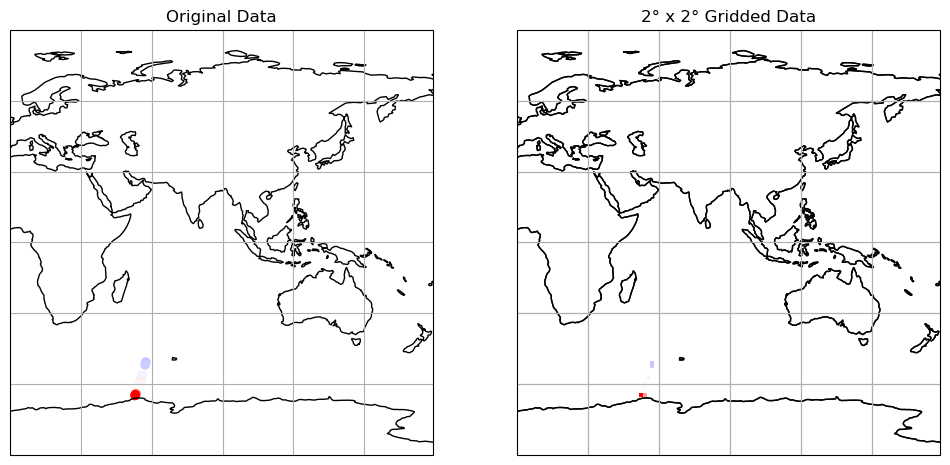

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10), subplot_kw={'projection':ccrs.PlateCarree()})

[a.set_extent([0, 179, -90, 90], ccrs.PlateCarree()) for a in axes]
[a.gridlines() for a in axes]
[a.coastlines() for a in axes]

axes[0].scatter(casts_dict["G2cfc11"].lon[:], 
                casts_dict["G2cfc11"].lat[:], 
                c = casts_dict["G2cfc11"].G2cfc11[13, :][:], vmin = 0, vmax = 1, transform=ccrs.PlateCarree(), cmap = "bwr")

axes[1].pcolormesh(vars_dicts["G2cfc11"].lon,
                   vars_dicts["G2cfc11"].lat, 
                   vars_dicts["G2cfc11"].G2cfc11[:, :, 13].T, 
                   vmin = 0, vmax = 1, 
                   transform=ccrs.PlateCarree(), cmap = "bwr", shading="auto|")

axes[1].set_extent([0, 179, -90, 90], ccrs.PlateCarree())
axes[1].gridlines()
axes[1].coastlines()

axes[0].set_title("Original Data")
axes[1].set_title("2° x 2° Gridded Data")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1762: UserWarning: shading value 'auto|' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  result = super().pcolormesh(*args, **kwargs)


Text(0.5, 1.0, '2° x 2° Gridded Data')

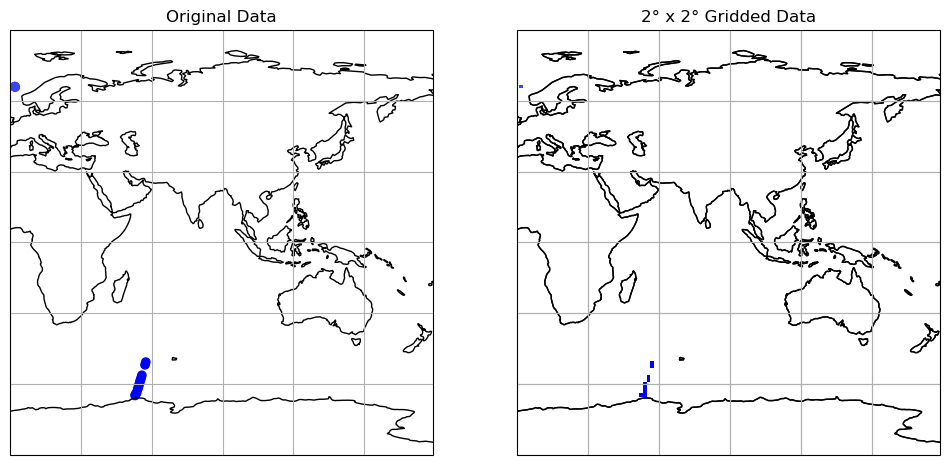

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10), subplot_kw={'projection':ccrs.PlateCarree()})

[a.set_extent([0, 179, -90, 90], ccrs.PlateCarree()) for a in axes]
[a.gridlines() for a in axes]
[a.coastlines() for a in axes]

axes[0].scatter(casts_dict["ct"].lon[:], 
                casts_dict["ct"].lat[:], 
                c = casts_dict["ct"].ct[13, :][:], vmin = 0, vmax = 10, transform=ccrs.PlateCarree(), cmap = "bwr")

axes[1].pcolormesh(vars_dicts["ct"].lon,
                   vars_dicts["ct"].lat, 
                   vars_dicts["ct"].ct[:, :, 13].T, 
                   vmin = 0, vmax = 10, 
                   transform=ccrs.PlateCarree(), cmap = "bwr", shading="auto|")

axes[1].set_extent([0, 179, -90, 90], ccrs.PlateCarree())
axes[1].gridlines()
axes[1].coastlines()

axes[0].set_title("Original Data")
axes[1].set_title("2° x 2° Gridded Data")

## Create a grid for all years 

In [8]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    
    varns = ["G2cfc12", "G2cfc11", "G2sf6", "sa", "ct", "G2depth", "G2pressure"]
    
    tregvars = dict()
    tcastvars =  dict()
    year_range = range(1990, 2021)
    for (tt, y) in enumerate(year_range):
        print("Percent Completed: ", tt / len(year_range))
    
        vars_dicts, casts_dict = GLODAP_2_regular_grid_custom_vertical(ds, gridded_sigma2, regular_lat, regular_lon, 
                                                    varns = varns, vertical_coord = "sigma2", year = y, binning_method = "mean")
        vars_dicts = xr.merge(vars_dicts.values())
        tregvars[y] = vars_dicts
    
    tmp_list = []
    for val in tregvars.values():
        tmp_list += [val.assign_coords({"time":val.time })]
    
    #save gridded data 
    GLODAP_gridded = xr.concat(tmp_list, dim = "time")
    GLODAP_gridded.to_netcdf("GLODAP_gridded_sigma.nc", compute = True)

Percent Completed:  0.0
Percent Completed:  0.03225806451612903
Percent Completed:  0.06451612903225806
Percent Completed:  0.0967741935483871
Percent Completed:  0.12903225806451613
Percent Completed:  0.16129032258064516
Percent Completed:  0.1935483870967742
Percent Completed:  0.22580645161290322
Percent Completed:  0.25806451612903225
Percent Completed:  0.2903225806451613
Percent Completed:  0.3225806451612903
Percent Completed:  0.3548387096774194
Percent Completed:  0.3870967741935484
Percent Completed:  0.41935483870967744
Percent Completed:  0.45161290322580644
Percent Completed:  0.4838709677419355
Percent Completed:  0.5161290322580645
Percent Completed:  0.5483870967741935
Percent Completed:  0.5806451612903226
Percent Completed:  0.6129032258064516
Percent Completed:  0.6451612903225806
Percent Completed:  0.6774193548387096
Percent Completed:  0.7096774193548387
Percent Completed:  0.7419354838709677
Percent Completed:  0.7741935483870968
Percent Completed:  0.8064516129

getfattr: /scratch/anthony.meza/CM4XAbyssalSWMT/notebooks/AABW_Thesis_Chapter2_DSW_Notebooks/GLODAP_gridded_sigma.nc: Operation not supported


## Plot composites

In [9]:
cfc_gridded = GLODAP_gridded["G2cfc12"]

Text(0.5, 1.0, 'CFC12 (2010 — 2020)')

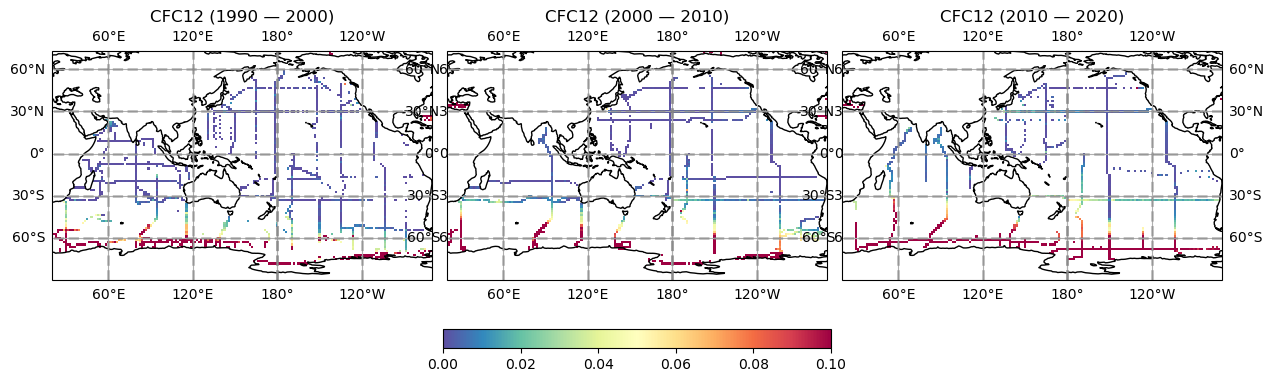

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 10), subplot_kw={'projection':ccrs.PlateCarree(central_longitude = 180)})
[a.set_extent([20, 290, -90, 73], ccrs.PlateCarree()) for a in axes]
[a.gridlines() for a in axes]
[a.coastlines() for a in axes]

cfc_gridded.sel(time = slice(1990, 2000), sigma2 = slice(None, None)).T.mean(["time", "sigma2"]).plot.pcolormesh(ax=axes[0], 
                                                                        vmin = 0, vmax = 0.1, cmap = "Spectral_r", 
                                                                        add_colorbar = False, transform=ccrs.PlateCarree())

cm = cfc_gridded.sel(time = slice(2000, 2010), sigma2 = slice(None, None)).T.mean(["time", "sigma2"]).plot.pcolormesh(ax=axes[1], 
                                                                        vmin = 0, vmax = 0.1, cmap = "Spectral_r", 
                                                                        add_colorbar = False, transform=ccrs.PlateCarree())
cfc_gridded.sel(time = slice(2010, 2020), sigma2 = slice(None, None)).T.mean(["time", "sigma2"]).plot.pcolormesh(ax=axes[2], 
                                                                                                             vmin = 0, vmax = 0.1, cmap = "Spectral_r", 
                                                                                                             add_colorbar = False, transform = ccrs.PlateCarree())
fig.tight_layout()
fig.colorbar(cm, ax = axes[:], orientation = "horizontal", fraction  = 0.02, pad = 0.05)

[a.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--') for a in axes]

axes[0].set_title("CFC12 (1990 — 2000)")
axes[1].set_title("CFC12 (2000 — 2010)")
axes[2].set_title("CFC12 (2010 — 2020)")